# Assignment 4: Regularization

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?
2. How does regularization provide a way of exploring the bias-variance trade-off?
3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?
4. How do we typically scale variables for use in regularized regression? Why?
5. How is the penalty $\alpha$ typically selected?
6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?

**Question 1:**

1. Adding a penalty makes large coefficients expensive, so the model prefers simpler solutions unless bigger coefficients truly improve fit. The takeaway is: it controls complexity and helps prevent overfitting.

2. Regularization lets us tune model complexity with the penalty size. More penalty gives higher bias but lower variance; less penalty gives lower bias but higher variance. The takeaway is: it gives a direct way to choose the best bias-variance balance.

3. LASSO uses an absolute value penalty and can set some coefficients exactly to zero, so it does variable selection. Ridge uses a squared penalty and usually only shrinks coefficients toward zero, not all the way to zero. The takeaway is: LASSO is more interpretable, Ridge usually keeps all predictors.

4. We usually standardize numeric variables to z-scores. Otherwise, variables on larger scales get penalized unfairly. The takeaway is that scaling makes the penalty comparable across predictors.

5. The penalty is usually chosen with cross-validation. We test many values of the penalty and pick the one with the lowest validation error. The takeaway is to choose the penalty based on out-of-sample performance.

6. No, we usually do not include the penalty term in the cross-validated MSE. We use the penalty only to fit the model on the training folds, then evaluate plain prediction error on the validation folds. The takeaway is: CV should measure how well the model predicts new data.



**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them.
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

In [1]:
! git clone https://github.com/anishjagota/undergrad_ml_assignments

Cloning into 'undergrad_ml_assignments'...
remote: Enumerating objects: 168, done.
remote: Counting objects: 100% (73/73), done.
remote: Compressing objects: 100% (47/47), done.
remote: Total 168 (delta 60), reused 26 (delta 26), pack-reused 95 (from 1)
Receiving objects: 100% (168/168), 15.68 MiB | 9.15 MiB/s, done.
Resolving deltas: 100% (75/75), done.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import LassoCV

In [3]:
#2.1
cars = pd.read_csv('/content/undergrad_ml_assignments/data/cars_hw.csv')
cars.head()
cars = cars.drop(columns=['Unnamed: 0'], errors='ignore')
cars['Age'] = 2024 - cars['Make_Year']
features = ['Mileage_Run', 'Age']
X = cars[features]
poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X)
poly_names = poly.get_feature_names_out(features)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)
X_scaled = pd.DataFrame(X_scaled, columns=poly_names)
X_scaled.head()


,Mileage_Run,Age,Mileage_Run^2,Mileage_Run Age,Age^2,Mileage_Run^3,Mileage_Run^2 Age,Mileage_Run Age^2,Age^3
0,0.124692,-0.013092,-0.137673,-0.075274,-0.193924,-0.294615,-0.247857,-0.243677,-0.319030
1,-0.872334,0.341858,-0.791316,-0.632282,0.150120,-0.661216,-0.697319,-0.524369,-0.022524
2,-0.493517,-0.722993,-0.600623,-0.687077,-0.744394,-0.581863,-0.652312,-0.702020,-0.701506
3,-0.241655,-0.013092,-0.434732,-0.307676,-0.193924,-0.492295,-0.460043,-0.382252,-0.319030
4,-0.674578,-0.013092,-0.700583,-0.582312,-0.193924,-0.627064,-0.649938,-0.546011,-0.319030


In [4]:
#2.2
y = cars['Price']

ols = LinearRegression()
ols.fit(X_scaled, y)

coef_table = pd.Series(ols.coef_, index=poly_names)
coef_table
coef_table['Mileage_Run Age']


np.float64(-1251592.3408260453)

In [5]:
#2.3

alphas = np.logspace(1, 3, 20)
lasso_cv = LassoCV(alphas=alphas, cv=20, max_iter=10000, random_state=100)
lasso_cv.fit(X_scaled, y)
lasso_cv.alpha_

np.float64(483.2930238571752)

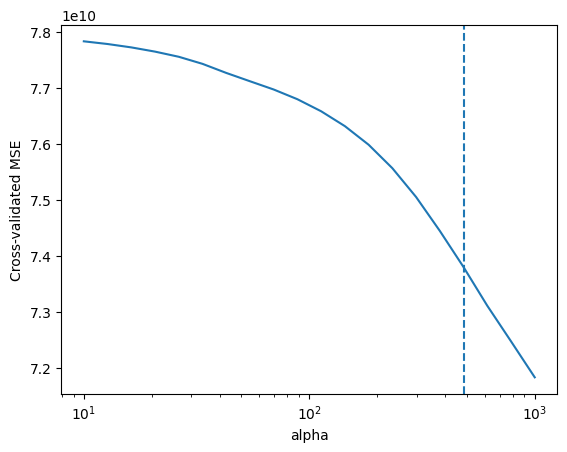

483.2930238571752


In [6]:
#2.4
median_mse = np.median(lasso_cv.mse_path_, axis=1)
alpha_star = lasso_cv.alpha_
plt.figure()
plt.plot(lasso_cv.alphas_, median_mse)
plt.axvline(x=alpha_star, linestyle='--')
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('Cross-validated MSE')
plt.show()

print(alpha_star)

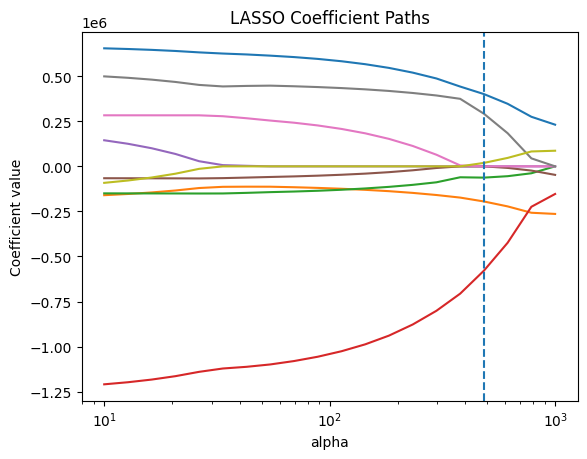

In [7]:
#2.5
coefs = []
for alpha in alphas:
    model = Lasso(alpha=alpha, max_iter=50000)
    model.fit(X_scaled, y)
    coefs.append(model.coef_)
coefs = np.array(coefs)
plt.figure()
for i in range(coefs.shape[1]):
    plt.plot(alphas, coefs[:, i], label=poly_names[i])

plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('Coefficient value')
plt.title('LASSO Coefficient Paths')
plt.axvline(x=alpha_star, linestyle='--')
plt.show()

In [8]:
#2.6
lasso_coef = pd.Series(lasso_cv.coef_, index=poly_names)
selected_features = lasso_coef[lasso_coef != 0]
zero_features = lasso_coef[lasso_coef == 0]
print("Selected features:")
print(selected_features)
print("\nNumber set to zero:", len(zero_features))
print("Total number of features:", len(lasso_coef))
print("Proportion set to zero:", len(zero_features) / len(lasso_coef))

Selected features:
Mileage_Run          401025.259657
Age                 -194803.116695
Mileage_Run^2        -62539.290093
Mileage_Run Age     -578788.661090
Mileage_Run Age^2    292015.025679
Age^3                 19133.908573
dtype: float64

Number set to zero: 3
Total number of features: 9
Proportion set to zero: 0.3333333333333333


In [9]:
#2.7
compare = pd.DataFrame({
    'OLS': coef_table,
    'LASSO': lasso_coef
})
compare['OLS_abs'] = compare['OLS'].abs()
compare['LASSO_abs'] = compare['LASSO'].abs()
compare['Increased_in_magnitude'] = compare['LASSO_abs'] > compare['OLS_abs']
compare['Changed_sign'] = np.sign(compare['OLS']) != np.sign(compare['LASSO'])
compare[['OLS', 'LASSO', 'Increased_in_magnitude', 'Changed_sign']]

,OLS,LASSO,Increased_in_magnitude,Changed_sign
Mileage_Run,6.686165e+05,401025.259657,False,False
Age,-1.841941e+05,-194803.116695,True,False
Mileage_Run^2,-1.494679e+05,-62539.290093,False,False
Mileage_Run Age,-1.251592e+06,-578788.661090,False,False
Age^2,2.156399e+05,-0.000000,False,True
Mileage_Run^3,-6.514490e+04,-0.000000,False,True
Mileage_Run^2 Age,2.833392e+05,0.000000,False,True
Mileage_Run Age^2,5.280829e+05,292015.025679,False,False
Age^3,-1.389370e+05,19133.908573,False,True


The LASSO coefficients are mostly smaller in magnitude than the OLS coefficients, so the main effect is shrinkage toward zero. The only coefficient that increases in magnitude is Age. Several terms are set exactly to zero, and the terms Age², Mileage_Run³, Mileage_Run² Age, and Age³ change sign because LASSO shrinks them to zero or near zero.

**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

In [10]:
import urllib.request
import os
import zipfile
import os

def download_data(force=False):
    """Download and extract course data from Zenodo."""

    zip_path = 'data.zip'
    data_dir = './data'

    if not os.path.exists(zip_path) or force:
        print("Downloading course data...")
        urllib.request.urlretrieve(
            'https://zenodo.org/records/18235955/files/data.zip?download=1',
            zip_path
        )
        print("Download complete")

    if not os.path.exists(data_dir) or force:
        print("Extracting data files...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(data_dir)
        print("Data extracted")

    return data_dir


if __name__ == "__main__":
    download_data()


Download complete
Extracting data files...
Data extracted


In [11]:
hf = pd.read_csv('/content/data/heart_failure_clinical_records_dataset.csv')
hf.head()


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [14]:
#3.1
num_features = ['age', 'ejection_fraction', 'serum_creatinine']
dum_features = ['anaemia', 'diabetes', 'high_blood_pressure', 'smoking']
X_num = hf[num_features]
X_dum = hf[dum_features]
poly_num = PolynomialFeatures(degree=3, include_bias=False)
X_num_poly = poly_num.fit_transform(X_num)
num_names = poly_num.get_feature_names_out(num_features)
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X_num_poly)
X_num_scaled = pd.DataFrame(X_num_scaled, columns=num_names)
poly_dum = PolynomialFeatures(degree=4, include_bias=False, interaction_only=True)
X_dum_int = poly_dum.fit_transform(X_dum)
dum_names = poly_dum.get_feature_names_out(dum_features)
X_dum_int = pd.DataFrame(X_dum_int, columns=dum_names)

X = pd.concat([X_num_scaled, X_dum_int], axis=1)
y = hf['DEATH_EVENT']
X.head()

,age,ejection_fraction,serum_creatinine,age^2,age ejection_fraction,age serum_creatinine,ejection_fraction^2,ejection_fraction serum_creatinine,serum_creatinine^2,age^3,...,anaemia high_blood_pressure,anaemia smoking,diabetes high_blood_pressure,diabetes smoking,high_blood_pressure smoking,anaemia diabetes high_blood_pressure,anaemia diabetes smoking,anaemia high_blood_pressure smoking,diabetes high_blood_pressure smoking,anaemia diabetes high_blood_pressure smoking
0,1.192945,-1.530560,0.490057,1.177180,-0.939354,0.777328,-1.197120,-0.287340,0.073541,1.124026,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-0.491279,-0.007077,-0.284552,-0.539187,-0.267742,-0.365953,-0.146835,-0.214284,-0.220393,-0.562311,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.350833,-1.530560,-0.090900,0.252982,-1.167019,-0.031334,-1.197120,-0.518041,-0.161606,0.152154,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-0.912335,-1.530560,0.490057,-0.885761,-1.508517,0.115061,-1.197120,-0.287340,0.073541,-0.835393,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.350833,-1.530560,1.264666,0.252982,-1.167019,1.237428,-1.197120,0.020262,0.524239,0.152154,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [15]:
#3.2
ols = LinearRegression()
ols.fit(X, y)
coef_table = pd.Series(ols.coef_, index=X.columns)
coef_table

,0
age,1.619432
ejection_fraction,-2.062277
serum_creatinine,-0.757092
age^2,-3.717758
age ejection_fraction,-0.800726
age serum_creatinine,1.707056
ejection_fraction^2,3.352956
ejection_fraction serum_creatinine,2.569764
serum_creatinine^2,-2.640240
age^3,1.963124


Some signs look counterintuitive. For example, a main effect may be positive while its squared term or interaction term is negative. This happens because, in a model with higher-order powers and interactions, one coefficient alone does not represent the full effect of that variable. The higher-order and interaction terms can resolve the apparent contradiction because they allow the effect of a variable to change with its level and with other variables. So the relationship is not purely linear, and the full effect comes from the combination of terms, not just the sign of one coefficient.

In [16]:
#3.3

alphas = np.logspace(5, 5, 30)
lasso_cv = LassoCV(alphas=alphas, cv=20, max_iter=50000, random_state=100)
lasso_cv.fit(X, y)
lasso_cv.alpha_

np.float64(100000.0)

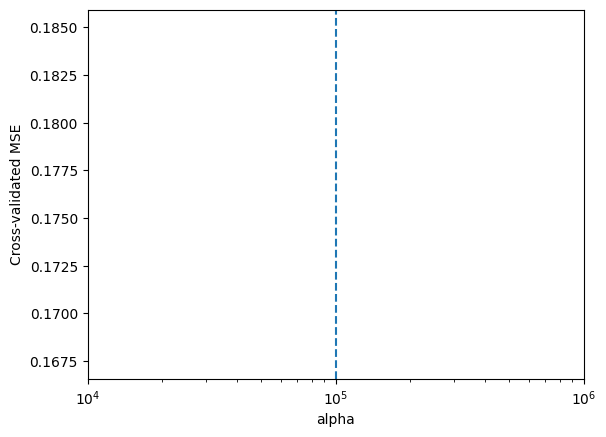

100000.0


In [18]:
# 3.4
median_mse = np.median(lasso_cv.mse_path_, axis=1)
alpha_star = lasso_cv.alpha_

plt.figure()
plt.plot(lasso_cv.alphas_, median_mse)
plt.axvline(x=alpha_star, linestyle='--')
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('Cross-validated MSE')
plt.show()
print(alpha_star)

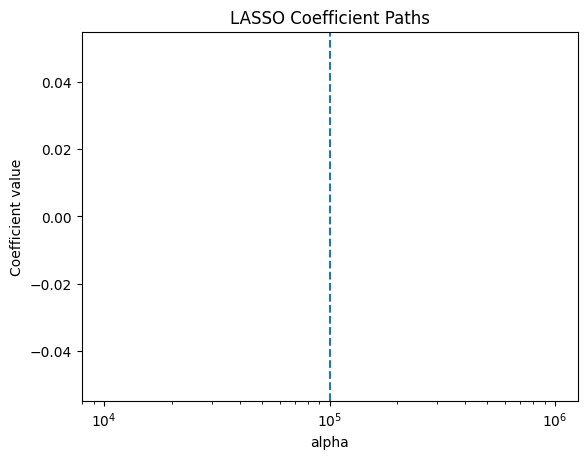

In [19]:
#3.5
coefs = []
for alpha in alphas:
    model = Lasso(alpha=alpha, max_iter=50000)
    model.fit(X, y)
    coefs.append(model.coef_)
coefs = np.array(coefs)
plt.figure()
for i in range(coefs.shape[1]):
    plt.plot(alphas, coefs[:, i])
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('Coefficient value')
plt.title('LASSO Coefficient Paths')
plt.axvline(x=alpha_star, linestyle='--')
plt.show()

In [21]:
# 3.6
lasso_coef = pd.Series(lasso_cv.coef_, index=X.columns)
selected_features = lasso_coef[lasso_coef != 0]
zero_features = lasso_coef[lasso_coef == 0]
print("Selected features:")
print(selected_features)
print("\nNumber set to zero:", len(zero_features))
print("Total number of features:", len(lasso_coef))
print("Proportion set to zero:", len(zero_features) / len(lasso_coef))

compare = pd.DataFrame({
    'OLS': coef_table,
    'LASSO': lasso_coef
})
compare['OLS_abs'] = compare['OLS'].abs()
compare['LASSO_abs'] = compare['LASSO'].abs()
compare['Increased_in_magnitude'] = compare['LASSO_abs'] > compare['OLS_abs']
compare['Changed_sign'] = np.sign(compare['OLS']) != np.sign(compare['LASSO'])
compare[['OLS', 'LASSO', 'Increased_in_magnitude', 'Changed_sign']]

Selected features:
Series([], dtype: float64)

Number set to zero: 34
Total number of features: 34
Proportion set to zero: 1.0


,OLS,LASSO,Increased_in_magnitude,Changed_sign
age,1.619432,0.0,False,True
ejection_fraction,-2.062277,-0.0,False,True
serum_creatinine,-0.757092,0.0,False,True
age^2,-3.717758,0.0,False,True
age ejection_fraction,-0.800726,-0.0,False,True
age serum_creatinine,1.707056,0.0,False,True
ejection_fraction^2,3.352956,-0.0,False,True
ejection_fraction serum_creatinine,2.569764,0.0,False,True
serum_creatinine^2,-2.640240,0.0,False,True
age^3,1.963124,0.0,False,True


The LASSO selects no features and sets all 34 coefficients to zero, so the proportion set to zero is 1.00. This happens mainly because the penalty is extremely large, and also because the alpha grid is np.logspace(5,5,30), which means every alpha value is the same: 100000. So LASSO is not really searching over different penalties; it is just applying one very large penalty, which shrinks every coefficient to zero. This reflects the bias-variance trade-off: variance is reduced a lot, but bias becomes too high.

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?
2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.
3. How does increasing $\alpha$ change the slope coefficient?
4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?

**Question 4:**

1. The objective function for ridge regression is the usual mean squared error plus a penalty on the slope coefficient 𝑏1. In words, we choose 𝑏0 and 𝑏1 to fit the data well, but we also penalize large values of b1 by adding 𝛼(𝑏1)^2 to the loss. The key takeaway is that ridge regression balances fit and simplicity by discouraging a large slope.

2. after taking the respective derivatives, we get:

b0=0

b1=[average of (x times y)] / [average of (x squared) + alpha]

This happens because both x and y are mean-centered, so the intercept drops out. Compared with OLS, the numerator stays the same, but ridge adds alpha to the denominator. The key takeaway is that ridge keeps the same basic slope formula as OLS, but the extra alpha in the denominator shrinks the slope toward zero.


3. As α increases, the slope coefficient b1 gets smaller in magnitude and is pushed toward 0. The key takeaway is that a larger ridge penalty means more shrinkage of the slope.

4. With the LASSO penalty α∣b1​∣, the main challenge is that the absolute value is not differentiable at 0, so we cannot solve it as smoothly as ridge by just taking ordinary derivatives everywhere. It is optimal to set b1=0 when the benefit from fitting the data is too small to justify the penalty. In this one-variable case, that happens when the correlation between x and y is small enough that the penalty dominates. The key takeaway is that LASSO can set the slope exactly equal to zero, which is why it performs variable selection.


